In [2]:
!pip install onnx onnxruntime onnxruntime-tools

  Using cached onnxruntime_tools-1.7.0-py3-none-any.whl.metadata (14 kB)
  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached py3nvml-0.2.7-py3-none-any.whl.metadata (13 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
  Using cached xmltodict-1.0.4-py3-none-any.whl.metadata (14 kB)
  Using cached pyreadline3-3.5.6-py3-none-any.whl.metadata (4.7 kB)
   ---------------------------------------- 0.0/7.9 MB ? eta -:--:--
   - -------------------------------------- 0.4/7.9 MB 7.4 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/7.9 MB 10.1 MB/s eta 0:00:01
   ------- -------------------------------- 1.5/7.9 MB 10.8 MB/s eta 0:00:01
   ----------- ---------------------------- 2.2/7.9 MB 11.8 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/7.9 MB 13.1 MB/s eta 0:00:01
   ------------------ --------------------- 3.6/7.9 MB 12.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/7.9 MB 1

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
astropy 5.3.4 requires numpy<2,>=1.21, but you have numpy 2.4.6 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.6 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.6 which is incompatible.
numba 0.59.0 requires numpy<1.27,>=1.22, but you have numpy 2.4.6 which is incompatible.
pandas 2.1.4 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.4.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.6 which is incompatible.
streamlit 1.30.0 requires numpy

In [1]:
import joblib

#import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("train.csv")

# Separate label and pixels
y = df["label"].values
X = df.drop(columns=["label"]).values

# Normalize pixels from 0-255 -> 0-1
X = X.astype("float32") / 255.0

# Reshape: (number of images, 784) -> (number of images, 28, 28)
X_image = X.reshape(-1, 28, 28)

print(X_image.shape)
print(y.shape)

(42000, 28, 28)
(42000,)


In [4]:
df_ = pd.read_csv("test.csv")

# Separate label and pixels
y_test = df["label"].values
X_test = df.drop(columns=["label"]).values

# Normalize pixels from 0-255 -> 0-1
X_test = X_test.astype("float32") / 255.0

print(X_test.shape)
print(y_test.shape)

(42000, 784)
(42000,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_val.shape)

(33600, 784)
(8400, 784)


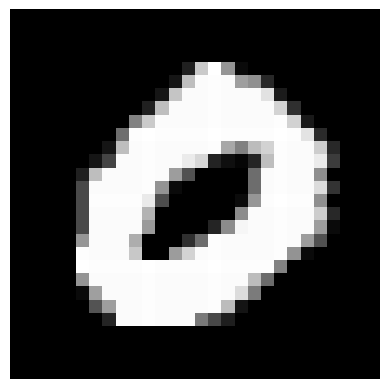

In [10]:
plt.imshow(X_train[4].reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    solver="adam",
    max_iter=200,
    random_state=42
)

param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.0005]
}

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Best CV accuracy: 0.9709523809523809


In [21]:
best_mlp = grid.best_estimator_

y_pred = best_mlp.predict(X_val)

In [ ]:
print("MLP Accuracy:", accuracy_score(y_val, y_pred))

print("\nMLP Classification Report:")
print(classification_report(y_val, y_pred))

MLP Accuracy: 0.9746428571428571

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       827
           1       0.98      0.99      0.99       937
           2       0.98      0.97      0.98       835
           3       0.97      0.95      0.96       870
           4       0.98      0.98      0.98       814
           5       0.96      0.97      0.97       759
           6       0.99      0.99      0.99       827
           7       0.98      0.98      0.98       880
           8       0.98      0.97      0.97       813
           9       0.95      0.96      0.96       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



In [23]:
# Save the model parameter
joblib.dump(best_mlp, "mlp_model.pkl")

['mlp_model.pkl']

In [24]:
mlp = joblib.load("mlp_model.pkl")
prediction = mlp.predict(X)

print("Predictions:", prediction)

Predictions: [1 0 1 ... 7 6 9]


## NEW MODEL

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.shape)
print(test_df.shape)

(42000, 785)
(28000, 784)


In [4]:
X = train_df.drop(columns=["label"]).values
y = train_df["label"].values

X_test = test_df.values

In [5]:
X = X.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

In [6]:
X = X.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

In [10]:
from torch import nn


class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 1 → 32
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 28 → 14

            # 32 → 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 14 → 7

            # 64 → 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

model = DigitCNN().to(device)

cpu


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [14]:
epochs = 20

for epoch in range(epochs):

    # ----------------
    # Training
    # ----------------
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_accuracy = train_correct / train_total


    # ----------------
    # Validation
    # ----------------
    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Train Loss: {train_loss/len(train_loader):.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss/len(val_loader):.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 1/20 Train Loss: 0.3380 Train Acc: 0.9368 Val Loss: 0.1439 Val Acc: 0.9560
Epoch 2/20 Train Loss: 0.0521 Train Acc: 0.9882 Val Loss: 0.0524 Val Acc: 0.9886
Epoch 3/20 Train Loss: 0.0353 Train Acc: 0.9914 Val Loss: 0.0547 Val Acc: 0.9855
Epoch 4/20 Train Loss: 0.0263 Train Acc: 0.9932 Val Loss: 0.0851 Val Acc: 0.9755
Epoch 5/20 Train Loss: 0.0217 Train Acc: 0.9942 Val Loss: 0.0611 Val Acc: 0.9845
Epoch 6/20 Train Loss: 0.0175 Train Acc: 0.9952 Val Loss: 0.0686 Val Acc: 0.9786
Epoch 7/20 Train Loss: 0.0157 Train Acc: 0.9957 Val Loss: 0.0434 Val Acc: 0.9869
Epoch 8/20 Train Loss: 0.0152 Train Acc: 0.9958 Val Loss: 0.0400 Val Acc: 0.9879
Epoch 9/20 Train Loss: 0.0086 Train Acc: 0.9977 Val Loss: 0.0310 Val Acc: 0.9907
Epoch 10/20 Train Loss: 0.0075 Train Acc: 0.9982 Val Loss: 0.0423 Val Acc: 0.9881
Epoch 11/20 Train Loss: 0.0068 Train Acc: 0.9983 Val Loss: 0.0487 Val Acc: 0.9881
Epoch 12/20 Train Loss: 0.0077 Train Acc: 0.9980 Val Loss: 0.0334 Val Acc: 0.9917
Epoch 13/20 Train Loss: 0

In [13]:
##model_path

model = DigitCNN()

state_dict = torch.load(
        "digit_cnn.pth",
        map_location="cpu"
)

model.load_state_dict(state_dict)
model.eval()

DigitCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, ker

In [23]:
dummy_input = torch.randn(1, 1, 28, 28)

torch.onnx.export(
    model,
    dummy_input,
    "digit_cnn.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batchsize"},
        "output": {0, "batchsize"}
    },
    opset_version=17,
)

print("Exported to digit_cnn.onnx")

C:\Users\Golazo\AppData\Local\Temp\ipykernel_8532\3182653799.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0924 13:00:14.523000 8532 Lib\site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0924 13:00:14.873000 8532 Lib\site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0924 13:00:14.875000 85

[torch.onnx] Obtain model graph for `DigitCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DigitCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


Traceback (most recent call last):
  File "c:\Users\Golazo\Documents\_Projects\digit_number\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "c:\Users\Golazo\Documents\_Projects\digit_number\.venv\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\Golazo\Documents\_Projects\digit_number\.venv\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\Golazo\Documents\_Projects\digit_number\.venv\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str 

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to digit_cnn.onnx


In [24]:
from pathlib import Path

for file in ["digit_cnn.onnx", "digit_cnn.onnx.data"]:
    path = Path(file)
    print(file, path.stat().st_size / 1024, "KB")

digit_cnn.onnx 24.8642578125 KB
digit_cnn.onnx.data 546.625 KB


In [25]:
from pathlib import Path

In [26]:
model_path = Path("digit_cnn.pth")

size_mb = model_path.stat().st_size / (1024 ** 2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 0.55 MB


In [27]:
# calibration dataloader
import numpy as np
from onnxruntime.quantization import CalibrationDataReader


class DigitCalibrationDataReader(CalibrationDataReader):

    def __init__(self, dataloader):
        self.dataloader = dataloader
        self.iterator = iter(dataloader)

    def get_next(self):
        try:
            images, _ = next(self.iterator)

            images = images.numpy().astype(np.float32)

            return {
                "input": images
            }

        except StopIteration:
            return None

In [28]:
import onnxruntime as ort

session = ort.InferenceSession("digit_cnn.onnx")

print(session.get_inputs()[0].name)
print(session.get_inputs()[0].shape)

input
['batchsize', 1, 28, 28]


In [29]:
from torch.utils.data import DataLoader, Subset

calibration_dataset = Subset(
    train_dataset,
    range(1000)
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=32,
    shuffle=False
)

In [30]:
calibration_reader = DigitCalibrationDataReader(
    calibration_loader
)

In [31]:
from onnxruntime.quantization import QuantFormat, QuantType, quantize_static

quantize_static(
    model_input="digit_cnn.onnx",
    model_output="digit_cnn_int8.onnx",
    calibration_data_reader=calibration_reader,
    quant_format=QuantFormat.QDQ,
    activation_type=QuantType.QInt8,
    weight_type=QuantType.QInt8
)

print("INT8 quantization complete!")

INT8 quantization complete!


In [ ]:
from pathlib import Path

files = [
    "digit_cnn.pth",
    "digit_cnn.onnx",
    "digit_cnn.onnx.data",
    "digit_cnn_int8.onnx",
    "digit_cnn_int8.onnx.data",
    
]

for file in files:
    path = Path(file)

    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"{file}: {size_kb:.2f} KB")

digit_cnn.pth: 564.43 KB
digit_cnn.onnx: 24.86 KB
digit_cnn.onnx.data: 546.62 KB
digit_cnn_int8.onnx: 162.83 KB


In [ ]:
#torch.save(model.state_dict(), "digit_cnn.pth")